In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
import os

# csv_path = '/content/drive/MyDrive/dataset/input_ball.csv'
base_path = './' 
csv_path = os.path.join(base_path, 'prediction', 'test_8sec_ball.csv')

def load_shuttle_pure(path):
    df = pd.read_csv(path)
    cols = {c.lower(): c for c in df.columns}
    x_col = cols.get('x') or cols.get('x_coord') or df.columns[2]
    y_col = cols.get('y') or cols.get('y_coord') or df.columns[3]

    # 보간(Interpolate), 필터링 전부 제거! 원본 그대로 사용
    x = df[x_col].fillna(0).values
    y = df[y_col].fillna(0).values
    return x, y

x_raw, y_raw = load_shuttle_pure(csv_path)
print(f"✅ {len(x_raw)} 프레임 원본 데이터 로드 완료")

✅ 239 프레임 원본 데이터 로드 완료


🏆 최종 완성 타점 (7개): [17, 30, 57, 85, 131, 162, 174]


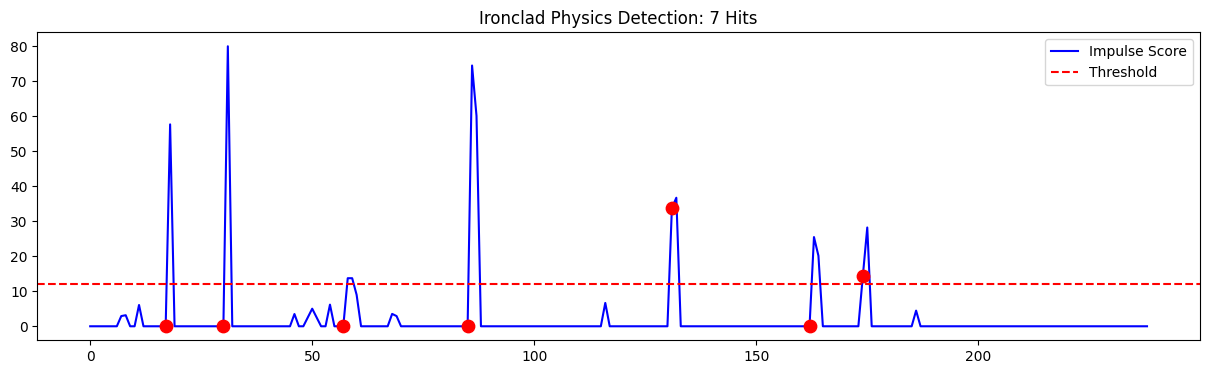

In [2]:
def detect_ironclad_physics_hits(x, y):
    scores = np.zeros(len(x))
    valid_idx = np.where((x > 0) & (y > 0))[0]

    valid_y = y[valid_idx]
    y_floor_limit = np.percentile(valid_y, 85) if len(valid_y) > 0 else 9999

    for k in range(2, len(valid_idx) - 2):
        i_curr = valid_idx[k]
        i_pre = valid_idx[k-2]
        i_post = valid_idx[k+2]

        dt_in = i_curr - i_pre
        dt_out = i_post - i_curr

        # 화면 밖 체공 무시
        if dt_in > 5 or dt_out > 5:
            continue

        v_in = np.array([x[i_curr] - x[i_pre], y[i_curr] - y[i_pre]]) / dt_in
        v_out = np.array([x[i_post] - x[i_curr], y[i_post] - y[i_curr]]) / dt_out

        speed_in = np.linalg.norm(v_in)
        speed_out = np.linalg.norm(v_out)

        # 미세한 트래킹 떨림 무시
        if speed_in < 3.0 and speed_out < 3.0:
            continue

        # 🚨 [방어 룰 1] 건너뛰기 직진성 검증 (Skip-Vector Check)
        # 현재 의심점(i_curr)을 무시하고, 과거(i_pre)에서 미래(i_post)로 바로 선을 긋습니다.
        v_skip = np.array([x[i_post] - x[i_pre], y[i_post] - y[i_pre]])
        norm_skip = np.linalg.norm(v_skip)
        norm_in = np.linalg.norm(v_in)

        if norm_skip > 1e-6 and norm_in > 1e-6:
            cos_skip = np.dot(v_in, v_skip) / (norm_in * norm_skip)
            angle_skip = np.degrees(np.arccos(np.clip(cos_skip, -1.0, 1.0)))

            # 궤적을 건너뛰어 연결했는데 원래 오던 방향과 15도 이내로 똑같다?
            # = 셔틀콕은 얌전히 직진 중이었는데 AI가 1프레임 기둥을 보고 좌표를 잘못 찍은 것!
            if angle_skip < 15:
                continue

        # 🚨 [방어 룰 2] 타격 후 잔여 비행 거리 (Flight Distance)
        future_idx = [idx for idx in valid_idx if idx > i_curr]
        if len(future_idx) < 3:
            continue # 타격 직후 영상 종료 시 무효

        final_x = x[future_idx[-1]]
        final_y = y[future_idx[-1]]
        flight_dist = np.sqrt((final_x - x[i_curr])**2 + (final_y - y[i_curr])**2)

        if flight_dist < 60:
            # 타격 후 화면상에서 60픽셀도 못 날아가고 트래킹이 끝났다면
            # 기둥/네트에 들러붙어 멈춰버린 가짜 타격(노이즈)입니다.
            continue

        # 충격량 계산 및 점수화 (스매시 가중치)
        impulse = np.linalg.norm(v_out - v_in)
        if v_out[1] - v_in[1] > 10:
            impulse *= 1.5

        # 바닥 오작동 방지 (튀어 오르지 않으면 무시)
        if y[i_curr] > y_floor_limit:
            future_check_idx = [idx for idx in valid_idx if i_curr < idx <= i_curr + 15]
            if future_check_idx:
                future_y = [y[idx] for idx in future_check_idx]
                if min(future_y) > y[i_curr] - 20:
                    continue

        scores[i_curr] = impulse

    # 상위 15% 이상만 타점으로 인정
    peak_thresh = np.max(scores) * 0.15 if np.max(scores) > 0 else 0
    hits, _ = find_peaks(scores, distance=12, prominence=1.0, height=peak_thresh)

    timing_offset = -1
    return [int(h + timing_offset) for h in hits if (h + timing_offset) > 0], scores

# 함수 실행
final_hits, impact_scores = detect_ironclad_physics_hits(x_raw, y_raw)
print(f"🏆 최종 완성 타점 ({len(final_hits)}개): {final_hits}")

# 결과 그래프
plt.figure(figsize=(15, 4))
plt.plot(impact_scores, label='Impulse Score', color='blue')
plt.scatter(final_hits, [impact_scores[i] for i in final_hits], color='red', s=80, zorder=3)
plt.axhline(y=np.max(impact_scores)*0.15, color='r', linestyle='--', label='Threshold')
plt.title(f"Ironclad Physics Detection: {len(final_hits)} Hits")
plt.legend()
plt.show()

In [5]:
import cv2
import numpy as np

# video_path = '/content/drive/MyDrive/dataset/test_8sec.mp4'
video_path = os.path.join(base_path, 'inputVideo', 'test_8sec.mp4')
# output_path = '/content/drive/MyDrive/dataset/qRallyTrack_Final_Fix.mp4'
output_path = os.path.join(base_path, 'result', 'result_impact.mp4')

cap = cv2.VideoCapture(video_path)
w, h, fps = int(cap.get(3)), int(cap.get(4)), cap.get(5)
out = cv2.VideoWriter(output_path, cv2.VideoWriter_fourcc(*'mp4v'), fps, (w, h))

f_idx = 0
while cap.isOpened():
    ret, frame = cap.read()
    if not ret: break

    if any(abs(f_idx - h) <= 1 for h in final_hits):
        cv2.putText(frame, "!!! IMPACT !!!", (w//2-180, 150), cv2.FONT_HERSHEY_DUPLEX, 2, (0,255,255), 5)
        frame[:, :, 2] = np.clip(frame[:, :, 2] + 80, 0, 255)

    if f_idx < len(x_raw) and x_raw[f_idx] > 0:
        cv2.circle(frame, (int(x_raw[f_idx]), int(y_raw[f_idx])), 12, (0, 255, 0), -1)

    cv2.putText(frame, f"F: {f_idx}", (30, 60), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 0), 2)

    out.write(frame)
    f_idx += 1

cap.release()
out.release()
# print(f"🎬 완벽한 7개 타점 영상 렌더링 완료: {output_path}")

final_fixed_path = os.path.join(base_path, 'result', 'final_impact_fixed.mp4')

# 아까 설치한 static_ffmpeg를 사용하여 코덱을 h.264로 재인코딩합니다.
!static_ffmpeg -y -i {output_path} -vcodec libx264 -pix_fmt yuv420p {final_fixed_path} -loglevel quiet

print(f"\n✨ 모든 재생기에서 열리는 최종본 생성 완료: {final_fixed_path}")



✨ 모든 재생기에서 열리는 최종본 생성 완료: ./result\final_impact_fixed.mp4
